In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_validate
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from scipy.stats import randint, uniform

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv('../dataset/processed/featured_data.csv')

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,price,city,locality,relaxation_amenity_count,security_amenity_count,...,service_staff_amenity_count,unclassify_amenity_count,division,zone,bedroom_not_applicable,log_area,total_rooms,bath_bed_ratio,area_per_bedroom,total_amenities
0,1185.0,Apartment,Residential,0.0,3.0,6100000.0,Dhaka,Khilgaon,0,1,...,0,3,Dhaka,Khilgaon,0,7.078342,3.0,0.000000,395.000000,8
1,2464.0,Apartment,Residential,4.0,3.0,28900000.0,Dhaka,Dhanmondi,0,2,...,0,4,Dhaka,Dhanmondi,0,7.809947,7.0,1.333333,821.333333,9
2,1140.0,Apartment,Residential,0.0,3.0,7500000.0,Dhaka,Mirpur,0,2,...,0,4,Dhaka,Mirpur,0,7.039660,3.0,0.000000,380.000000,10
3,1920.0,Apartment,Residential,3.0,3.0,20000000.0,Dhaka,Bashundhara R-A,0,1,...,0,3,Dhaka,Bashundhara R/A,0,7.560601,6.0,1.000000,640.000000,9
4,1445.0,Apartment,Residential,3.0,3.0,10800000.0,Dhaka,Banasree,0,0,...,0,4,Dhaka,Khilgaon,0,7.276556,6.0,1.000000,481.666667,7


In [3]:
X = df.drop(columns=['price'])
y = df['price']

In [4]:
print(X.shape)
print(y.shape)

(12665, 22)
(12665,)


In [5]:
X.head()

,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,city,locality,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,...,service_staff_amenity_count,unclassify_amenity_count,division,zone,bedroom_not_applicable,log_area,total_rooms,bath_bed_ratio,area_per_bedroom,total_amenities
0,1185.0,Apartment,Residential,0.0,3.0,Dhaka,Khilgaon,0,1,2,...,0,3,Dhaka,Khilgaon,0,7.078342,3.0,0.000000,395.000000,8
1,2464.0,Apartment,Residential,4.0,3.0,Dhaka,Dhanmondi,0,2,0,...,0,4,Dhaka,Dhanmondi,0,7.809947,7.0,1.333333,821.333333,9
2,1140.0,Apartment,Residential,0.0,3.0,Dhaka,Mirpur,0,2,2,...,0,4,Dhaka,Mirpur,0,7.039660,3.0,0.000000,380.000000,10
3,1920.0,Apartment,Residential,3.0,3.0,Dhaka,Bashundhara R-A,0,1,2,...,0,3,Dhaka,Bashundhara R/A,0,7.560601,6.0,1.000000,640.000000,9
4,1445.0,Apartment,Residential,3.0,3.0,Dhaka,Banasree,0,0,2,...,0,4,Dhaka,Khilgaon,0,7.276556,6.0,1.000000,481.666667,7


In [6]:
y.head()

0     6100000.0
1    28900000.0
2     7500000.0
3    20000000.0
4    10800000.0
Name: price, dtype: float64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.20)

In [8]:
print(X_train.shape)
print(X_test.shape)

(10132, 22)
(2533, 22)


In [9]:
X_test.to_csv('../dataset/processed/test_data.csv', index=False)

In [10]:
numeric_feature = X_train.select_dtypes(
    include = ['int64', 'float64']
).columns.tolist()

categorical_feature = X_train.select_dtypes(
    include = ['object', 'string', 'category']
).columns.tolist()

print("Numerical feature:")
print(numeric_feature)

print('Categorical feature:')
print(categorical_feature)

Numerical feature:
['area', 'num_bath_rooms', 'num_bed_rooms', 'relaxation_amenity_count', 'security_amenity_count', 'maintenance_or_cleaning_amenity_count', 'social_amenity_count', 'expendable_amenity_count', 'service_staff_amenity_count', 'unclassify_amenity_count', 'bedroom_not_applicable', 'log_area', 'total_rooms', 'bath_bed_ratio', 'area_per_bedroom', 'total_amenities']
Categorical feature:
['building_type', 'building_nature', 'city', 'locality', 'division', 'zone']


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [12]:
categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            )
        )
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_feature
        ),
        (
            'cat',
            categorical_transformer,
            categorical_feature
        )
    ]
)

In [14]:
models = {
    'Linear Regressor': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [15]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    #Predict
    y_pred = pipeline.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print("-" * 50)

Training Linear Regressor...


MAE:  4,879,513.57
RMSE: 16,301,437.64
R²:   0.3807
--------------------------------------------------
Training Ridge...
MAE:  4,863,063.37
RMSE: 16,254,576.80
R²:   0.3843
--------------------------------------------------
Training Lasso...


e:\ml_project\bangladesh-real-estate-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.479824e+18, tolerance: 1.127e+15
  model = cd_fast.sparse_enet_coordinate_descent(


MAE:  4,880,170.72
RMSE: 16,301,391.43
R²:   0.3807
--------------------------------------------------
Training RandomForestRegressor...
MAE:  2,432,519.69
RMSE: 15,846,874.69
R²:   0.4148
--------------------------------------------------
Training DecisionTreeRegressor...
MAE:  2,903,718.79
RMSE: 19,180,698.58
R²:   0.1427
--------------------------------------------------
Training GradientBoostingRegressor...
MAE:  3,025,438.24
RMSE: 14,577,163.38
R²:   0.5048
--------------------------------------------------
Training XGBRegressor...
MAE:  2,713,311.34
RMSE: 15,173,799.81
R²:   0.4635
--------------------------------------------------


In [16]:
results_df = pd.DataFrame(results)

results_df.sort_values(by='R2', ascending=False)

,Model,MAE,RMSE,R2
5,GradientBoostingRegressor,3.025438e+06,1.457716e+07,0.504819
6,XGBRegressor,2.713311e+06,1.517380e+07,0.463454
3,RandomForestRegressor,2.432520e+06,1.584687e+07,0.414799
1,Ridge,4.863063e+06,1.625458e+07,0.384300
2,Lasso,4.880171e+06,1.630139e+07,0.380748
0,Linear Regressor,4.879514e+06,1.630144e+07,0.380745
4,DecisionTreeRegressor,2.903719e+06,1.918070e+07,0.142672


Ridge and Lasso perform virtually identically to plain Linear Regression (barely any improvement). This suggests regularization isn't the bottleneck — the problem isn't overfitting, it's that the model itself is too simple (linear) or missing important signal, not that it's picking up noise from too many features.

In [17]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_cv = cross_validate(
    ridge_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

In [19]:
ridge_cv_mae = -ridge_cv["test_mae"]
ridge_cv_rmse = -ridge_cv["test_rmse"]
ridge_cv_r2 = ridge_cv["test_r2"]

print("Ridge 5-Fold Cross-Validation")
print("--------------------------------")

print(f"MAE : ৳{ridge_cv_mae.mean():,.2f}")
print(f"RMSE: ৳{ridge_cv_rmse.mean():,.2f}")
print(f"R²  : {ridge_cv_r2.mean():.4f}")

print("\nFold R²:")
print(ridge_cv_r2)

Ridge 5-Fold Cross-Validation
--------------------------------
MAE : ৳6,327,878.95
RMSE: ৳56,902,757.85
R²  : -2.4483

Fold R²:
[  0.47487178  -2.75671059   0.51400807   0.3590023  -10.83274266]


In [20]:
lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])

lasso_cv = cross_validate(
    lasso_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

In [21]:
lasso_cv_mae = -lasso_cv["test_mae"]
lasso_cv_rmse = -lasso_cv["test_rmse"]
lasso_cv_r2 = lasso_cv["test_r2"]

print("Lasso 5-Fold Cross-Validation")
print("--------------------------------")

print(f"MAE : ৳{lasso_cv_mae.mean():,.2f}")
print(f"RMSE: ৳{lasso_cv_rmse.mean():,.2f}")
print(f"R²  : {lasso_cv_r2.mean():.4f}")

print("\nFold R²:")
print(lasso_cv_r2)

Lasso 5-Fold Cross-Validation
--------------------------------
MAE : ৳6,338,114.17
RMSE: ৳56,095,674.57
R²  : -2.3299

Fold R²:
[  0.47054006  -2.77714766   0.50756146   0.35347429 -10.20381729]


In [22]:
ridge_params = {
    'model__alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

ridge_grid = GridSearchCV(
    ridge_model,
    param_grid=ridge_params,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best CV RMSE:", -ridge_grid.best_score_)

Best Ridge alpha: {'model__alpha': 0.001}
Best CV RMSE: 56090108.96214936


The best RMSE from tuning (৳56.07M) is almost identical to the RMSE you got before tuning (৳56.90M). This is an important negative result: it confirms that the problem you found in the last step (the -10.84 fold blowing everything up) is not a regularization issue.

Also worth noting: the grid search picked alpha = 0.001, which is essentially no regularization at all (very close to plain Linear Regression). If regularization were helping stabilize the model, the search would have picked a larger alpha. The fact that it picked the smallest value in your grid tells you Ridge isn't finding anything worth "shrinking" — the instability is coming from outliers or fold composition, not from overfitting/coefficient size.

In [23]:
lasso_params = {
    'model__alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ],
    'model__max_iter': [
        50000
    ]
}

lasso_grid = GridSearchCV(
    lasso_model,
    param_grid=lasso_params,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Ridge alpha:", lasso_grid.best_params_)
print("Best CV RMSE:", -lasso_grid.best_score_)

Best Ridge alpha: {'model__alpha': 0.001, 'model__max_iter': 50000}
Best CV RMSE: 56095241.85006748


e:\ml_project\bangladesh-real-estate-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.645361e+18, tolerance: 1.127e+15
  model = cd_fast.sparse_enet_coordinate_descent(


In [24]:
print("Training price statistics:")
print(y_train.describe())

print("\nTest price statistics:")
print(y_test.describe())

Training price statistics:
count    1.013200e+04
mean     1.192775e+07
std      3.334633e+07
min      6.000000e+04
25%      5.000000e+06
50%      7.200000e+06
75%      1.125000e+07
max      2.076200e+09
Name: price, dtype: float64

Test price statistics:
count    2.533000e+03
mean     1.088852e+07
std      2.071938e+07
min      2.730000e+05
25%      5.000000e+06
50%      7.150000e+06
75%      1.112000e+07
max      7.000000e+08
Name: price, dtype: float64


In [25]:
print("\nTraining price quantiles:")
print(
    y_train.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.0]
    )
)

print("\nTest price quantiles:")
print(
    y_test.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.0]
    )
)


Training price quantiles:
0.500    7.200000e+06
0.750    1.125000e+07
0.900    1.950000e+07
0.950    2.900000e+07
0.990    8.700000e+07
0.995    1.386900e+08
1.000    2.076200e+09
Name: price, dtype: float64

Test price quantiles:
0.500      7150000.0
0.750     11120000.0
0.900     18940000.0
0.950     25000000.0
0.990     61411840.0
0.995    105000000.0
1.000    700000000.0
Name: price, dtype: float64


In [26]:
y_log = np.log1p(y)

In [27]:
print("Original price:")
print(y.describe())

print("\nLog-transformed price:")
print(y_log.describe())

Original price:
count    1.266500e+04
mean     1.171990e+07
std      3.123410e+07
min      6.000000e+04
25%      5.000000e+06
50%      7.200000e+06
75%      1.120000e+07
max      2.076200e+09
Name: price, dtype: float64

Log-transformed price:
count    12665.000000
mean        15.887001
std          0.717576
min         11.002117
25%         15.424949
50%         15.789592
75%         16.231424
max         21.453805
Name: price, dtype: float64


In [28]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [29]:
results_log = []
fitted_pipelines = {}

for name, model in models.items():

    print(f"Training {name} with log target...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train using LOG(price)
    pipeline.fit(X_train, y_train_log)
    fitted_pipelines[name] = pipeline

    # Predict log(price)
    y_pred_log = pipeline.predict(X_test)

    # Convert predictions back to original price
    y_pred = np.expm1(y_pred_log)

    # Evaluate against original price
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results_log.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE:  ৳{mae:,.2f}")
    print(f"RMSE: ৳{rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print("-" * 50)

Training Linear Regressor with log target...
MAE:  ৳2,954,666.12
RMSE: ৳14,860,303.41
R²:   0.4854
--------------------------------------------------
Training Ridge with log target...
MAE:  ৳2,951,181.49
RMSE: ৳14,839,369.60
R²:   0.4868
--------------------------------------------------
Training Lasso with log target...
MAE:  ৳5,963,291.87
RMSE: ৳20,920,745.33
R²:   -0.0199
--------------------------------------------------
Training RandomForestRegressor with log target...
MAE:  ৳2,310,503.40
RMSE: ৳14,691,408.92
R²:   0.4970
--------------------------------------------------
Training DecisionTreeRegressor with log target...
MAE:  ৳2,807,463.62
RMSE: ৳17,026,310.31
R²:   0.3244
--------------------------------------------------
Training GradientBoostingRegressor with log target...
MAE:  ৳2,830,154.20
RMSE: ৳14,765,508.17
R²:   0.4919
--------------------------------------------------
Training XGBRegressor with log target...
MAE:  ৳2,249,678.05
RMSE: ৳9,189,514.25
R²:   0.8032
--------

In [30]:
xgb_model = fitted_pipelines['XGBRegressor']

xgb_log_pred = xgb_model.predict(X_test)

xgb_pred = np.expm1(xgb_log_pred)

In [31]:
comparison = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': xgb_pred
})

comparison['Absolute_Error'] = (
    np.abs(
        comparison['Actual_Price'] - 
        comparison['Predicted_Price']
    )
)

display(
    comparison.sort_values(
        'Absolute_Error',
        ascending=False
    ).head(20)
)

,Actual_Price,Predicted_Price,Absolute_Error
872,700000000.0,493208832.0,206791168.0
1428,260000000.0,65118564.0,194881436.0
523,150000000.0,15957806.0,134042194.0
1687,302240000.0,170212224.0,132027776.0
178,200000000.0,75098112.0,124901888.0
2154,140000000.0,43252572.0,96747428.0
882,2700000.0,97806576.0,95106576.0
303,120000000.0,32283096.0,87716904.0
1762,280000000.0,198449792.0,81550208.0
1764,25000000.0,91943888.0,66943888.0


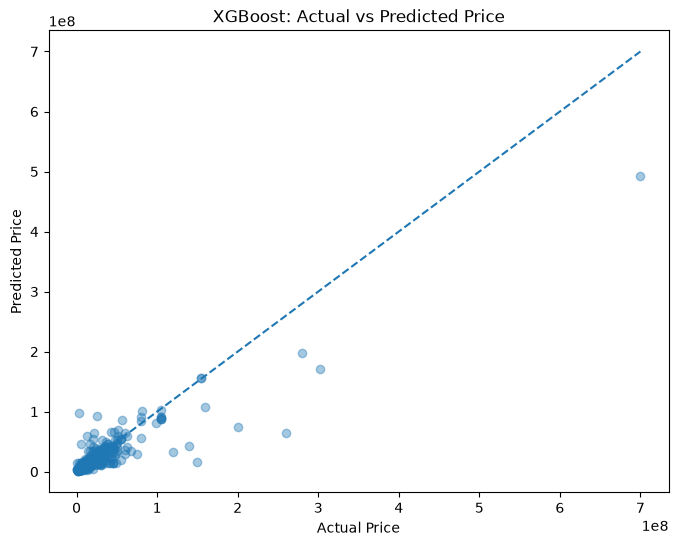

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

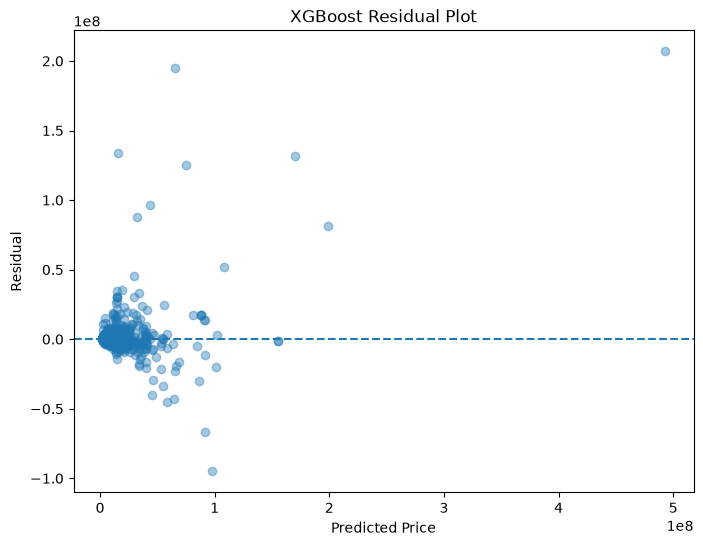

In [33]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("XGBoost Residual Plot")

plt.show()

In [34]:
xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

xgb_cv_rmse = -xgb_cv['test_rmse']
xgb_cv_r2 = xgb_cv['test_r2']

print("XGBoost Log-Target Cross Validation")
print("-----------------------------------")

print(
    f"RMSE: {xgb_cv_rmse.mean():.4f} "
    f"+/- {xgb_cv_rmse.std():.4f}"
)

print(
    f"R²: {xgb_cv_r2.mean():.4f} "
    f"+/- {xgb_cv_r2.std():.4f}"
)

print("\nFold R²:")
print(xgb_cv_r2)

XGBoost Log-Target Cross Validation
-----------------------------------
RMSE: 0.3082 +/- 0.0249
R²: 0.8189 +/- 0.0265

Fold R²:
[0.76840957 0.83780143 0.82761252 0.84179783 0.81870172]


In [35]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            XGBRegressor(
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [36]:
param_distributions = {
    "model__n_estimators": randint(300, 1000),

    "model__learning_rate": uniform(0.01, 0.09),

    "model__max_depth": randint(3, 10),

    "model__min_child_weight": randint(1, 10),

    "model__subsample": uniform(0.7, 0.3),

    "model__colsample_bytree": uniform(0.7, 0.3),

    "model__gamma": uniform(0, 0.5),

    "model__reg_alpha": uniform(0, 1),

    "model__reg_lambda": uniform(0.5, 2)
}

In [37]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [38]:
xgb_random_search.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....001AE7957EC10>, 'model__gamma': <scipy.stats....001AE79462780>, 'model__learning_rate': <scipy.stats....001AE79442CF0>, 'model__max_depth': <scipy.stats....001AE7957E490>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_

In [39]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV R²:")
print(xgb_random_search.best_score_)

Best Parameters:
{'model__colsample_bytree': np.float64(0.7886901057513142), 'model__gamma': np.float64(0.052747129915135305), 'model__learning_rate': np.float64(0.051088111343461924), 'model__max_depth': 6, 'model__min_child_weight': 4, 'model__n_estimators': 630, 'model__reg_alpha': np.float64(0.32434502100527396), 'model__reg_lambda': np.float64(0.7441759094013467), 'model__subsample': np.float64(0.8068893514230924)}

Best CV R²:
0.8292165315751605


In [40]:
best_xgb = xgb_random_search.best_estimator_

tuned_pred_log = best_xgb.predict(X_test)

tuned_pred = np.expm1(tuned_pred_log)

In [41]:
tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned XGBoost")
print("--------------")
print(f"MAE : ৳{tuned_mae:,.2f}")
print(f"RMSE: ৳{tuned_rmse:,.2f}")
print(f"R²  : {tuned_r2:.4f}")

Tuned XGBoost
--------------
MAE : ৳2,286,252.95
RMSE: ৳10,935,522.74
R²  : 0.7213


In [42]:
# Tuned model predictions in log-price space
tuned_pred_log = best_xgb.predict(X_test)

# R² on log-price scale
tuned_log_r2 = r2_score(
    y_test_log,
    tuned_pred_log
)

tuned_log_mae = mean_absolute_error(
    y_test_log,
    tuned_pred_log
)

tuned_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        tuned_pred_log
    )
)

print("Tuned XGBoost - Log Scale Test Performance")
print("-------------------------------------------")
print(f"Log MAE : ৳{tuned_log_mae:,.2f}")
print(f"Log RMSE: {tuned_log_rmse:.4f}")
print(f"Log R²  : {tuned_log_r2:.4f}")

Tuned XGBoost - Log Scale Test Performance
-------------------------------------------
Log MAE : ৳0.16
Log RMSE: 0.2705
Log R²  : 0.8432


In [43]:
baseline_pred_log = xgb_model.predict(X_test)

baseline_log_r2 = r2_score(
    y_test_log,
    baseline_pred_log
)

baseline_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        baseline_pred_log
    )
)

print("Baseline XGBoost - Log Scale Test Performance")
print("----------------------------------------------")
print(f"Log RMSE: {baseline_log_rmse:.4f}")
print(f"Log R²  : {baseline_log_r2:.4f}")

Baseline XGBoost - Log Scale Test Performance
----------------------------------------------
Log RMSE: 0.2724
Log R²  : 0.8409


In [44]:
results_log

[{'Model': 'Linear Regressor',
  'MAE': 2954666.123204319,
  'RMSE': np.float64(14860303.408045415),
  'R2': 0.4853958539798261},
 {'Model': 'Ridge',
  'MAE': 2951181.4911447098,
  'RMSE': np.float64(14839369.602385977),
  'R2': 0.4868446851586662},
 {'Model': 'Lasso',
  'MAE': 5963291.871642351,
  'RMSE': np.float64(20920745.332793146),
  'R2': -0.019934384764311197},
 {'Model': 'RandomForestRegressor',
  'MAE': 2310503.3975179056,
  'RMSE': np.float64(14691408.920197684),
  'R2': 0.497026827149774},
 {'Model': 'DecisionTreeRegressor',
  'MAE': 2807463.6206148923,
  'RMSE': np.float64(17026310.310548473),
  'R2': 0.32444763897754747},
 {'Model': 'GradientBoostingRegressor',
  'MAE': 2830154.1956442897,
  'RMSE': np.float64(14765508.172926622),
  'R2': 0.49194032715673586},
 {'Model': 'XGBRegressor',
  'MAE': 2249678.0452684565,
  'RMSE': np.float64(9189514.248535225),
  'R2': 0.8032099942006612}]

In [45]:
xgb_mae = results_log[-1].get('MAE')
xgb_rmse = results_log[-1].get('RMSE')
xgb_r2 = results_log[-1].get('R2')

In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    
    "Test_Log_RMSE": [
        baseline_log_rmse,
        tuned_log_rmse
    ],
    
    "Test_Log_R2": [
        baseline_log_r2,
        tuned_log_r2
    ],
    
    "Test_MAE": [
        xgb_mae,
        tuned_mae
    ],
    
    "Test_RMSE": [
        xgb_rmse,
        tuned_rmse
    ],
    
    "Test_R2": [
        xgb_r2,
        tuned_r2
    ]
})

comparison

,Model,Test_Log_RMSE,Test_Log_R2,Test_MAE,Test_RMSE,Test_R2
0,Baseline XGBoost,0.272422,0.840908,2.249678e+06,9.189514e+06,0.803210
1,Tuned XGBoost,0.270485,0.843162,2.286253e+06,1.093552e+07,0.721326


In [47]:
import shap

In [48]:
final_model = best_xgb

In [49]:
preprocessor_fitted = final_model.named_steps['preprocessor']

xgb_model_fitted = final_model.named_steps['model']

X_test_transformed = preprocessor_fitted.transform(X_test)

In [50]:
print(X_test_transformed.shape)

(2533, 276)


In [51]:
feature_names = preprocessor_fitted.get_feature_names_out()

print('Number of features:', len(feature_names))
print(feature_names)

Number of features: 276
['num__area' 'num__num_bath_rooms' 'num__num_bed_rooms'
 'num__relaxation_amenity_count' 'num__security_amenity_count'
 'num__maintenance_or_cleaning_amenity_count' 'num__social_amenity_count'
 'num__expendable_amenity_count' 'num__service_staff_amenity_count'
 'num__unclassify_amenity_count' 'num__bedroom_not_applicable'
 'num__log_area' 'num__total_rooms' 'num__bath_bed_ratio'
 'num__area_per_bedroom' 'num__total_amenities'
 'cat__building_type_Apartment' 'cat__building_type_Building'
 'cat__building_type_Commercial Plot' 'cat__building_type_Duplex'
 'cat__building_type_House' 'cat__building_type_Office'
 'cat__building_type_Others' 'cat__building_type_Residential Plot'
 'cat__building_type_Shop' 'cat__building_nature_Commercial'
 'cat__building_nature_Residential' 'cat__city_Bandarban'
 'cat__city_Barguna' 'cat__city_Bogura' 'cat__city_Chandpur'
 'cat__city_Chattogram' 'cat__city_Chittagong' 'cat__city_Cumilla'
 'cat__city_Dhaka' 'cat__city_Gazipur' 'cat__cit

In [52]:
explainer = shap.TreeExplainer(
    xgb_model_fitted
)

In [53]:
shap_values = explainer(
    X_test_transformed
)

In [54]:
X_test_sample = X_test_transformed[:1000]

shap_values_sample = explainer(
    X_test_sample
)

In [55]:
if hasattr(X_test_sample, 'toarray'):
    X_test_sample_dense = X_test_sample.toarray()
else:
    X_test_sample_dense = X_test_sample

# Create DataFrame with feature names
X_test_shap_df = pd.DataFrame(
    X_test_sample_dense,
    columns=feature_names
)

print(X_test_shap_df.shape)
X_test_shap_df.head()

(1000, 276)


,num__area,num__num_bath_rooms,num__num_bed_rooms,num__relaxation_amenity_count,num__security_amenity_count,num__maintenance_or_cleaning_amenity_count,num__social_amenity_count,num__expendable_amenity_count,num__service_staff_amenity_count,num__unclassify_amenity_count,...,cat__zone_Sub-district of Narsingdi,cat__zone_Sub-district of Rajshahi,cat__zone_Sub-district of Rangpur,cat__zone_Sub-district of Satkhira,cat__zone_Sub-district of Sherpur,cat__zone_Sutrapur,cat__zone_Sylhet City,cat__zone_Tejgaon,cat__zone_Turag,cat__zone_Uttara
0,-0.104095,0.950080,0.105002,-0.101681,1.666643,0.684968,-0.240782,0.043926,0.0,0.828907,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.193928,0.330154,-0.310738,-0.101681,-0.953642,-1.236166,-0.240782,0.687074,0.0,0.197964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.185544,0.950080,0.105002,-0.101681,-0.953642,-1.236166,-0.240782,-1.242371,0.0,0.828907,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.140028,0.950080,0.105002,-0.101681,0.356501,-0.275599,-0.240782,0.687074,0.0,0.197964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.125655,-0.909698,0.105002,-0.101681,0.356501,0.684968,-0.240782,1.973371,0.0,1.459850,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
shap_explanation = shap.Explanation(
    values=shap_values_sample.values,
    base_values=shap_values_sample.base_values,
    data=X_test_shap_df.values,
    feature_names=feature_names
)

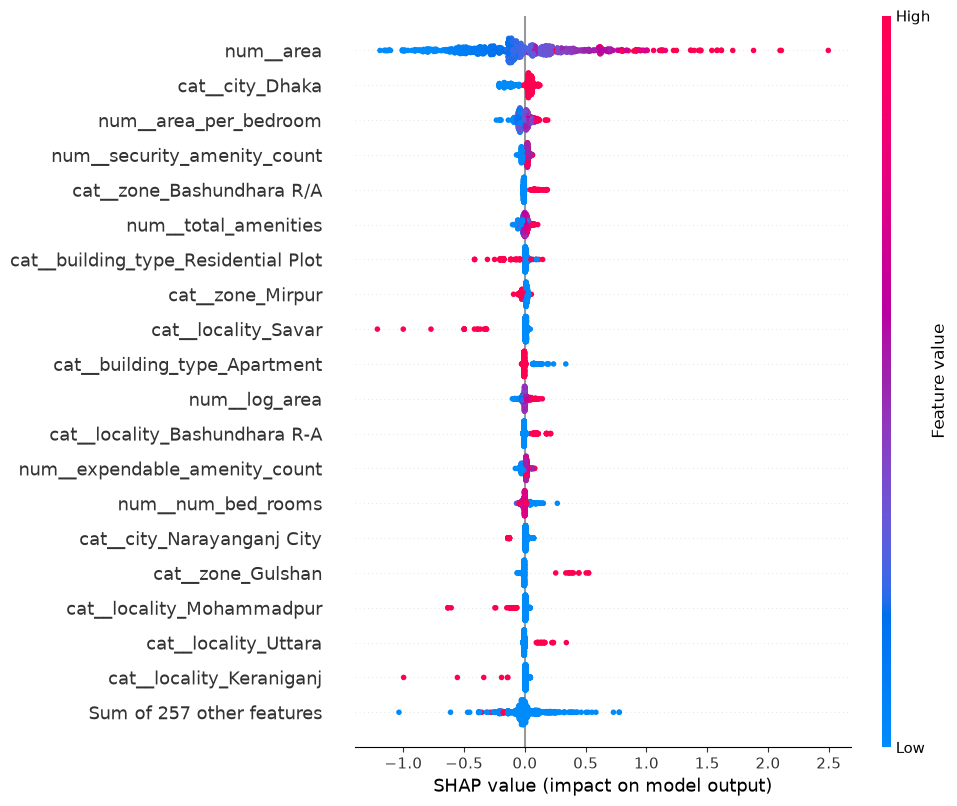

In [57]:
shap.plots.beeswarm(
    shap_explanation,
    max_display=20
)

1. area is overwhelmingly the most influential feature, exactly as expected. The color pattern is clean and intuitive: large area (pink, high value) strongly pushes predicted price up, small area (blue) pushes it down. This confirms and quantifies what the correlation matrix showed earlier (0.72 with log price) — area is doing most of the work.
2. Location dominates the rest of the top features. cat__city_Dhaka, cat__zone_Bashundhara R/A, cat__zone_Gulshan, cat__locality_Bashundhara R-A, cat__locality_Savar all show strong, clear effects:
   - Being in Gulshan or Bashundhara R/A (pink) pushes predictions noticeably higher — consistent with the earlier "top expensive localities" table.
   - Being in Savar shows a strong negative push (pink dots sitting at -1.0 to -0.5) — this is one of the largest single effects on the whole plot, confirming Savar is a meaningfully cheaper area in this data.
   - This is a good validation moment: the model rediscovered, purely from data, the exact premium-vs-affordable pattern it found manually back in the city/locality price tables.
3. num_bed_rooms shows a counter-intuitive pattern — high bedroom counts (pink) cluster toward negative SHAP values, while low bedroom counts (blue) push toward positive. This lines up directly with what it found in the bedroom-price table: beyond the common 1–7 range, bedroom count became unreliable and inconsistent (tiny samples, wild price swings). The model is picking up on that same noise, which is a good thing to flag in this report as a known data limitation rather than a "true" relationship.
4. Amenities (security_amenity_count, expendable_amenity_count, total_amenities) have smaller but consistent positive effects — more amenities modestly increases predicted price, as we'd expect.
5. "Sum of 257 other features" is worth pausing on. That's a huge number of low-impact features — almost certainly from one-hot encoding locality/zone/city, which have very high cardinality. Most of these individually contribute almost nothing (thin spread near 0), but collectively add a lot of dimensionality.

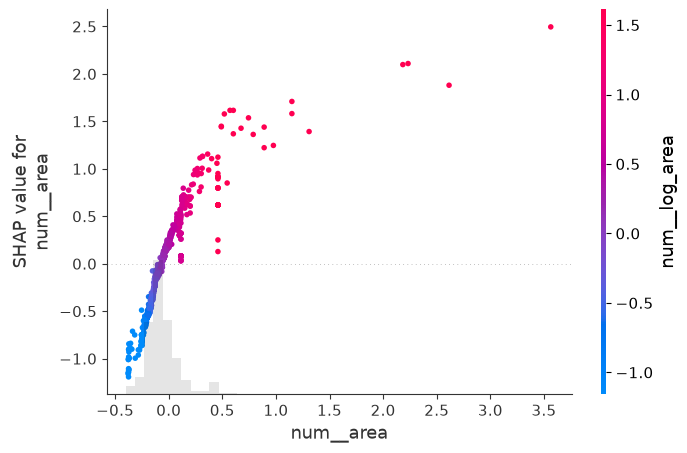

In [58]:
shap.plots.scatter(
    shap_explanation[:, 'num__area'],
    color=shap_explanation
)

This plot shows area has a diminishing-returns effect on price — going from small to medium area matters a lot, but going from large to very large adds comparatively less per additional square foot. This is genuinely how real estate often works in practice (a jump from 500 to 1,500 sqft matters more to buyers/price than 10,000 to 15,000 sqft).

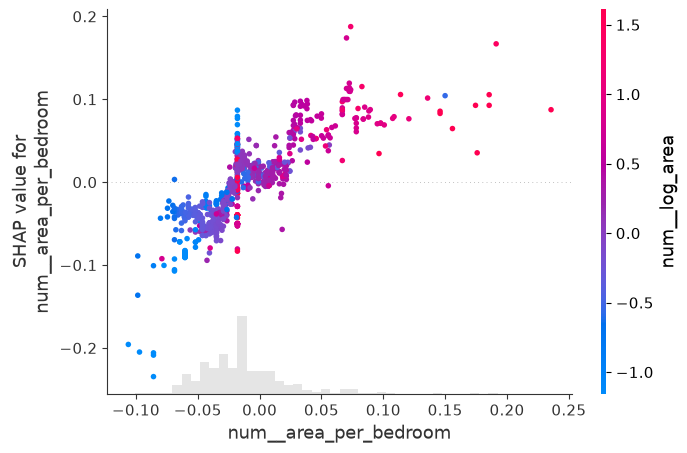

In [59]:
shap.plots.scatter(
    shap_explanation[:, "num__area_per_bedroom"],
    color=shap_explanation
)

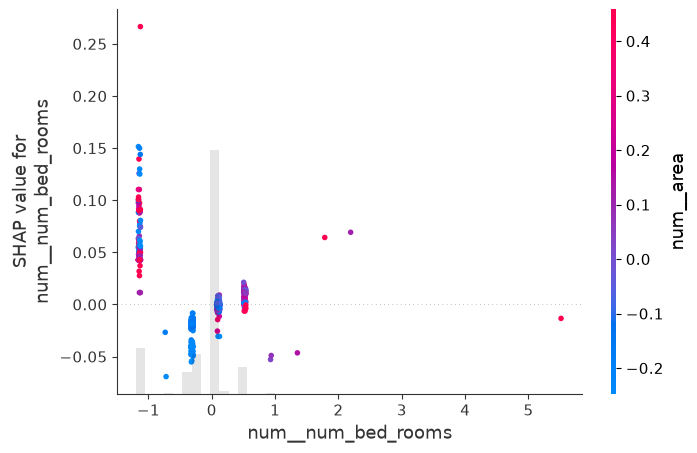

In [60]:
shap.plots.scatter(
    shap_explanation[:, "num__num_bed_rooms"],
    color=shap_explanation
)

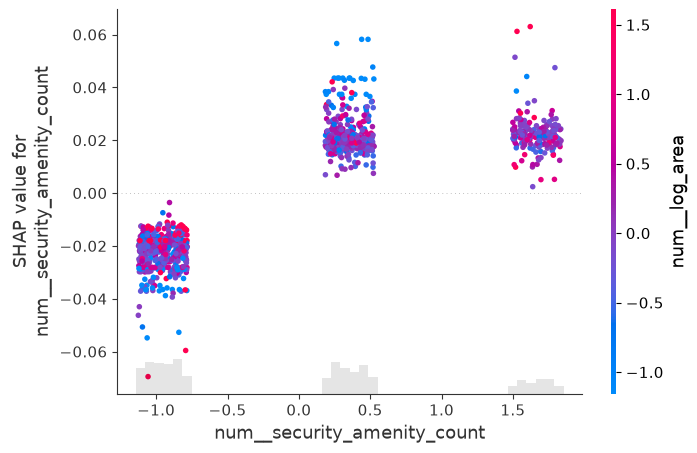

In [61]:
shap.plots.scatter(
    shap_explanation[:, "num__security_amenity_count"],
    color=shap_explanation
)

In [62]:
# ==========================================
# LOCAL SHAP EXPLANATION
# ==========================================

sample_index = 0

sample_features = X_test_shap_df.iloc[sample_index]

sample_shap = shap_explanation[sample_index]

print("Actual Price:")
print(f"৳{y_test.iloc[sample_index]:,.2f}")

predicted_log_price = xgb_model_fitted.predict(
    X_test_transformed[sample_index:sample_index + 1]
)[0]

predicted_price = np.expm1(predicted_log_price)

print("\nPredicted Price:")
print(f"৳{predicted_price:,.2f}")

Actual Price:
৳7,500,000.00

Predicted Price:
৳7,161,493.50


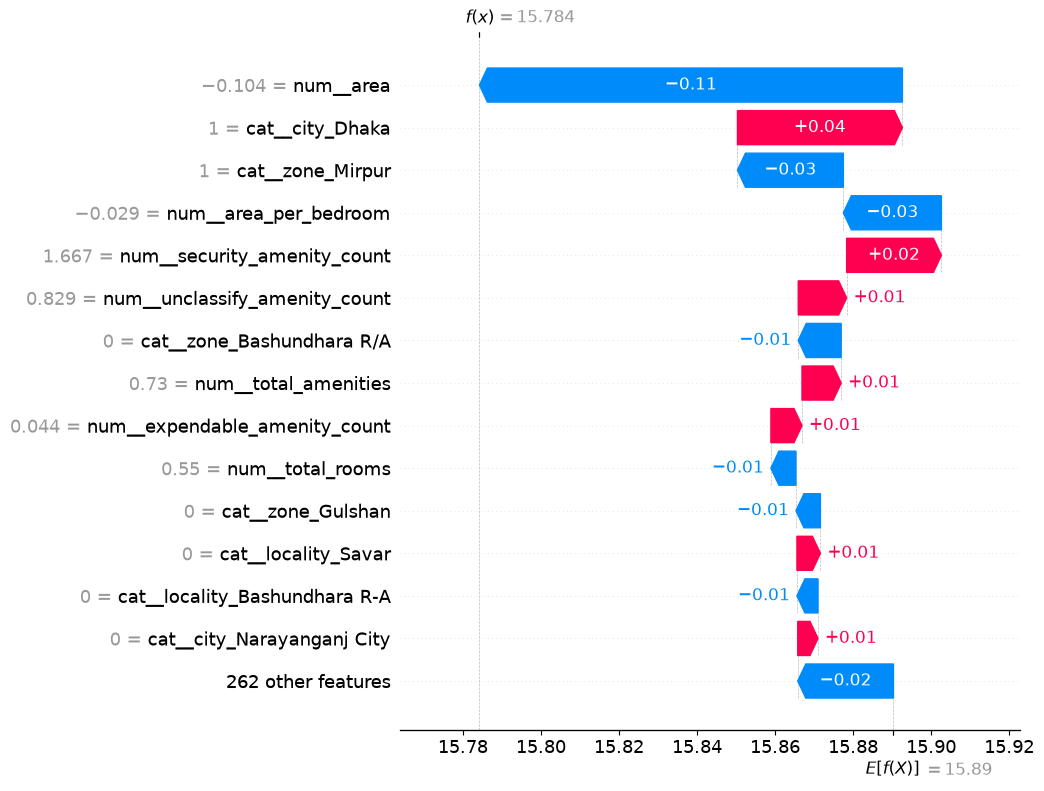

In [63]:
shap.plots.waterfall(
    sample_shap,
    max_display=15
)

In [64]:
import os
import joblib

ARTIFACT_DIR = '../models/'

os.makedirs(ARTIFACT_DIR, exist_ok=True)

model_path = os.path.join(
    ARTIFACT_DIR,
    'real_estate_price_model.joblib'
)

joblib.dump(
    final_model,
    model_path
)

print('Model saved successfully!')
print(model_path)

Model saved successfully!
../models/real_estate_price_model.joblib


In [65]:
import json

REPORT_path = '../reports/'

results_path = os.path.join(
    REPORT_path,
    'result_log.json'
)

with open(results_path, 'w') as f:
    json.dump(
        results_log,
        f,
        indent=4
    )

    print('Result saved:')
    print(results_path)

Result saved:
../reports/result_log.json


In [66]:
comparison_path = os.path.join(
    REPORT_path,
    'model_comparison.csv'
)

comparison.to_csv(
    comparison_path,
    index=False
)

print('Model comparison saved:')
print(comparison_path)

Model comparison saved:
../reports/model_comparison.csv


In [67]:
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(
        shap_values_sample.values
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
).reset_index(drop=True)

shap_importance['rank'] = (
    shap_importance.index + 1
)

shap_importance.head(20)

,feature,mean_abs_shap,rank
0,num__area,0.343875,1
1,cat__city_Dhaka,0.062459,2
2,num__area_per_bedroom,0.036469,3
3,num__security_amenity_count,0.022572,4
4,cat__zone_Bashundhara R/A,0.018286,5
5,num__total_amenities,0.017976,6
6,cat__building_type_Residential Plot,0.017960,7
7,cat__zone_Mirpur,0.017877,8
8,cat__locality_Savar,0.017128,9
9,cat__building_type_Apartment,0.016953,10


In [68]:
feature_importance_path = os.path.join(
    REPORT_path,
    'feature_importance.csv'
)

shap_importance.to_csv(
    feature_importance_path,
    index=False
)

print('Feature importance saved:')
print(feature_importance_path)

Feature importance saved:
../reports/feature_importance.csv


In [69]:
feature_names_path = os.path.join(
    REPORT_path,
    "feature_names.json"
)

with open(feature_names_path, "w") as f:
    json.dump(
        feature_names.tolist(),
        f,
        indent=4
    )

print("Feature names saved.")

Feature names saved.


In [70]:
# ==========================================
# MODEL METADATA
# ==========================================

metadata = {
    "model_name": "XGBoost",
    "target": "price",
    "target_transformation": "log1p",
    "prediction_inverse_transformation": "expm1",

    "dataset": "Bangladesh Real Estate - Sale Properties",

    "test_metrics": {
        "MAE": float(tuned_mae),
        "RMSE": float(tuned_rmse),
        "R2": float(tuned_r2),
        "Log_MAE": float(tuned_log_mae),
        "Log_RMSE": float(tuned_log_rmse),
        "Log_R2": float(tuned_log_r2)
    },

    "num_features_after_preprocessing": int(
        len(feature_names)
    ),

    "shap_samples": 1000
}

metadata_path = os.path.join(
    REPORT_path,
    "model_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved:")
print(metadata_path)

Metadata saved:
../reports/model_metadata.json
